# Square-Wave VRM/SMU Analysis — Interpretable Edition

These cells drop in **after** your existing setup (after `run_node_data`, `run_power_data`, `run_clock_data`, and `cycle_counts` are populated — i.e. after your current cell 19/22).

Each cell answers exactly one question:

| # | Question |
|---|---|
| **A1** | What does an average cycle look like at each frequency? |
| **A2** | One picture: how does cycle shape change as switching gets faster? |
| **A3** | How big is the actual swing, and where is the −3 dB knee? |
| **A4** | How much time does the GPU spend at peak vs trough vs in transition? |
| **A5** | What's the peak slew rate? Is it asymmetric (VRM up vs down)? |
| **A6** | Does switching cost extra energy per operation? |
| **A7** | When in each cycle does the brake (throttle) hit? |

Every cell is self-contained, robust, and produces a real graph.

In [23]:
from IPython.display import display
import re
from ampere import Ensemble, Metric, MetricConfig, MetricType, AmpereSession, Visualizer, connect, DataFrame, set_backend, ak
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

import os
from glob import glob
# Connect to Arkouda (registers cleanup automatically)
set_backend('pandas')
connect(server="localhost", port=5555)

Pandas backend active — skipping Arkouda connection.


## Shared helpers (run once)

In [24]:
# TRACES=[
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-1",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-4",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-16",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-64",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-128",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-256",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-512",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-1024",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-2048",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-4096",
#     "/Users/adam/Documents/python/ampere/examples/gemm-traces-9/cycles-8192",
# ]
TRACES=sorted([str(x) for x in glob("/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-*")], key=lambda s: int(s.split('-')[-1]))
TRACES

['/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-1',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-2',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-3',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-4',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-5',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-6',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-8',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-10',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-12',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-15',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-18',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-24',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-30',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-45',
 '/Users/hom/Documents/ampere/examples/gemm-traces-13/cycles-60',
 '/Users/hom/Docu

In [25]:
# Define Metric Configs
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    re.compile(r".*rocm.*violation.*"): MetricConfig(MetricType.CUMULATIVE),
    re.compile(r".*rocm.*clk.*"): MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-9),
}

# Define Topology Resolver
def my_hpc_topology(metric_name, ranks):
    # if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    # if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    # if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    # if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    # if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=1' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=3' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    return ranks

In [26]:
# ranks = [f"MPI Rank {i}" for i in range(8)]
ranks = ["Process"]
topo = {"Node0": ranks}
ensemble = Ensemble.from_trace_paths(TRACES, topo, configs)
# Shared constants used by all subsequent plots
cycle_counts = [int(t.split('cycles-')[-1]) for t in TRACES]


Loading Runs: 100%|██████████| 32/32 [00:00<00:00, 66.91it/s]


In [27]:

# Derive instantaneous power from cumulative energy
def calc_power(energy_metric):
    # def numerical_derivative(func, h=0.001):
    #     return lambda t: (func(t + h) - func(t - h)) / (2 * h)
    # t = energy_metric.times.to_ndarray()
    # e = energy_metric.values.to_ndarray()
    # f = lambda x: np.interp(x, t, e)
    # f = numerical_derivative(f)
    # power = f(t)
    # return Metric("power", ak.array(t), ak.array(power), MetricConfig(MetricType.INSTANTANEOUS))
    
    t = energy_metric.times
    e = energy_metric.values
    dt = t[1:] - t[:-1]
    de = e[1:] - e[:-1]
    power = de / dt
    power = ak.where((power < 0) | (dt <= 0), 0.0, power)
    return Metric("power", t[1:], power, MetricConfig(MetricType.INSTANTANEOUS))

for d in [0, 2, 4, 6]:
    ensemble.add_derived_metric(
        f"A2rocm_smi:::inst_power:device={d}",
        calc_power,
        f"A2rocm_smi:::energy_count:device={d}"
    )

Deriving metric 'A2rocm_smi:::inst_power:device=0'...
Deriving metric 'A2rocm_smi:::inst_power:device=2'...
Deriving metric 'A2rocm_smi:::inst_power:device=4'...
Deriving metric 'A2rocm_smi:::inst_power:device=6'...


In [28]:
def calc_combined_gpu_power(*power_metrics):
    values = []
    lens = [len(metric.times) for metric in power_metrics]
    l = min(lens)
    for i in range(l):
        values.append(sum([metric.values[i] for metric in power_metrics]))
    times = None
    for metric in power_metrics:
        if times is None or len(metric.times) < len(times):
            times = metric.times
    return Metric('combined_gpu_power', times, np.array(values), MetricConfig(MetricType.INSTANTANEOUS))

ensemble.add_derived_metric(
    f"A2rocm_smi:::combined_gpu_power",
    calc_combined_gpu_power,
    f"A2rocm_smi:::inst_power:device=0",
    f"A2rocm_smi:::inst_power:device=2",
    f"A2rocm_smi:::inst_power:device=4",
    f"A2rocm_smi:::inst_power:device=6",
)

Deriving metric 'A2rocm_smi:::combined_gpu_power'...


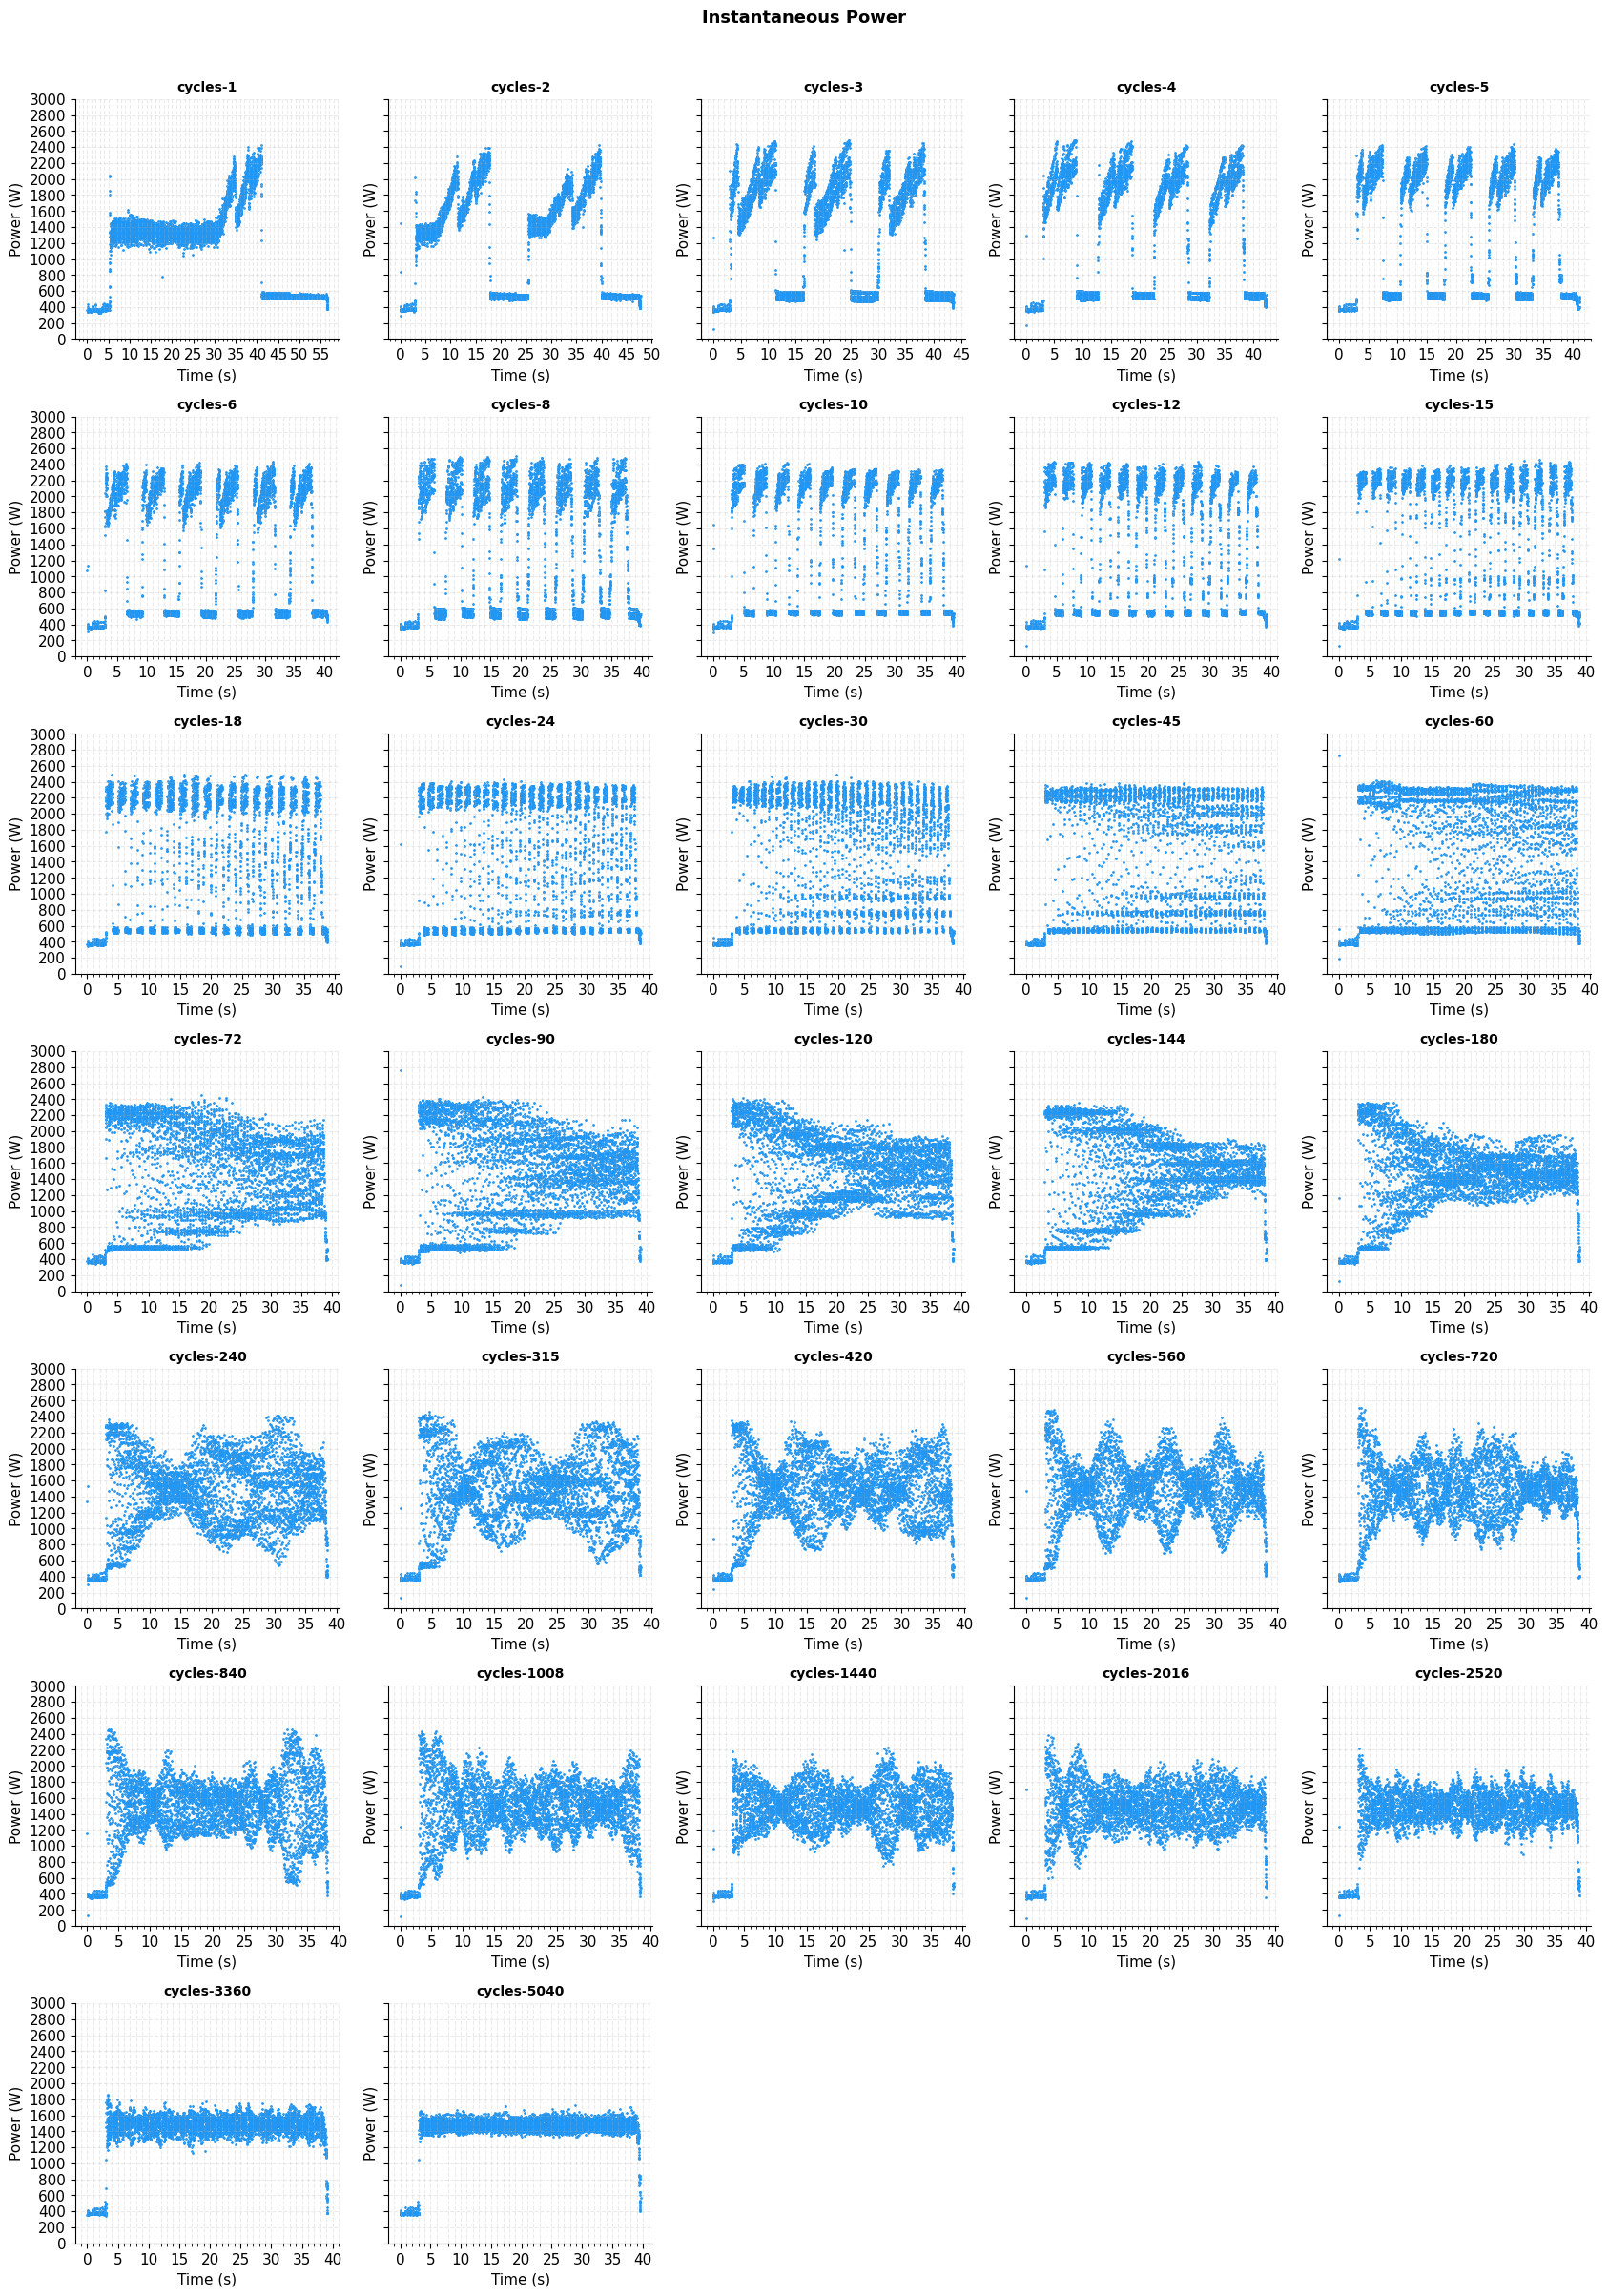

In [29]:
run_node_data     = []
run_gpu_data = []
for run in ensemble.runs:
    y_p = run.nodes[0].metrics["A2rocm_smi:::combined_gpu_power"]
    t_p = np.asarray(y_p.times)
    p   = np.asarray(y_p.values)

    if "A2coretemp:::craypm:power" in run.nodes[0].metrics:
        y_c = run.nodes[0].metrics["A2coretemp:::craypm:power"]
        t_c = np.asarray(y_c.times)
        c   = np.asarray(y_c.values)
        run_node_data.append(((t_p, p), (t_c, c)))
    else:
        run_node_data.append(((t_p, p), (None, None)))
    y_p = run.nodes[0].metrics["A2rocm_smi:::inst_power:device=0"]
    t_p = np.asarray(y_p.times)
    p   = np.asarray(y_p.values)
    run_gpu_data.append(((t_p, p), None))


ncols = 5
nrows = (len(ensemble.runs) + ncols - 1) // ncols

# --- Power grid ---
fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 3.4), sharey=True)
fig.suptitle("Instantaneous Power",
             fontsize=13, fontweight='bold', y=1.01)
for i, (ax, ((combined_gpu_t, combined_gpu_p), (node_t, node_p))) in enumerate(zip(axes.flat, run_node_data)):
    ax.set_title(f"cycles-{cycle_counts[i]}", fontsize=10, fontweight='bold')
    # y = ensemble.runs[TRACE_NUMBER].nodes[0].metrics["A2rocm_smi:::combined_gpu_power"]
    # t = np.asarray(y.times)
    # e = np.asarray(y.values)
    ax.scatter(combined_gpu_t, combined_gpu_p, color='#2196F3', label='Combined GPU Power', s=1)
    # y = ensemble.runs[TRACE_NUMBER].nodes[0].metrics["A2coretemp:::craypm:power"]
    # t = np.asarray(y.times)
    # e = np.asarray(y.values)
    if node_t is not None:
        ax.scatter(node_t, node_p, color='red', label='Node Power', s=1)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Power (W)")
    ax.grid(True, which='both')

    ax.yaxis.set_major_locator(MultipleLocator(200))
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.set_ybound(0, 3000)
    ax.set_ylim(0, 3000)
    

    # For the minor ticks, use no labels; default NullFormatter.
    ax.xaxis.set_minor_locator(AutoMinorLocator())

for ax in axes.flat[len(run_node_data):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

N_RUNS = len(cycle_counts)
PALETTE = plt.cm.plasma(np.linspace(0.15, 0.88, N_RUNS))
THROTTLE_LOW, THROTTLE_HIGH = 0.8, 1.7   # GHz - throttle clock band

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
    'font.size':         11,
})


def fold_cycles(t, y, n_cycles, t_skip_head=3.0, t_skip_tail=1.0,
                n_phase_bins=400):
    """Fold N cycles of a periodic signal onto a single canonical cycle.
    Returns a dict with 'phase' (0..1), 'median', 'p10', 'p25', 'p75', 'p90',
    'period_s', 'stack' (n_cycles x n_phase_bins), 'n_cycles_used'."""
    t = np.asarray(t, dtype=float); y = np.asarray(y, dtype=float)
    mask = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, y = t[mask], y[mask]
    if len(t) < 64 or n_cycles < 1:
        return None
    duration = t[-1] - t[0]
    period = duration / n_cycles
    phase = ((t - t[0]) / period) % 1.0
    cycle_id = ((t - t[0]) // period).astype(int)
    phase_grid = np.linspace(0, 1, n_phase_bins, endpoint=False)
    n_used = max(1, int(cycle_id.max()))
    stack = np.full((n_used, n_phase_bins), np.nan)
    for k in range(n_used):
        sel = cycle_id == k
        if sel.sum() < 4:
            continue
        order = np.argsort(phase[sel])
        ph_k = phase[sel][order]
        y_k = y[sel][order]
        _, uniq = np.unique(ph_k, return_index=True)
        if len(uniq) < 4:
            continue
        stack[k] = np.interp(phase_grid, ph_k[uniq], y_k[uniq])
    if np.all(np.isnan(stack)):
        return None
    return dict(
        phase=phase_grid, period_s=period, stack=stack,
        median=np.nanmedian(stack, axis=0),
        p10=np.nanpercentile(stack, 10, axis=0),
        p25=np.nanpercentile(stack, 25, axis=0),
        p75=np.nanpercentile(stack, 75, axis=0),
        p90=np.nanpercentile(stack, 90, axis=0),
        n_cycles_used=int(np.sum(~np.all(np.isnan(stack), axis=1))),
    )


def f0_of_run(i):
    (gpu_t, _), _ = run_node_data[i]
    return cycle_counts[i] / (gpu_t[-1] - gpu_t[0])


## A1 — What does an average cycle look like at each frequency?

**The idea:** every run contains N cycles of a known period. Fold them onto a single cycle (phase 0..1) and stack them. The median across cycles is the noise-suppressed average response; the band shows cycle-to-cycle jitter.

**How to read it:** if the loop is fully tracking, you'll see a clean square wave shape. If the loop is bandwidth-limited, you'll see rounded edges and a smaller peak-to-peak. If it's lost completely, you'll see a flat line at the mean.

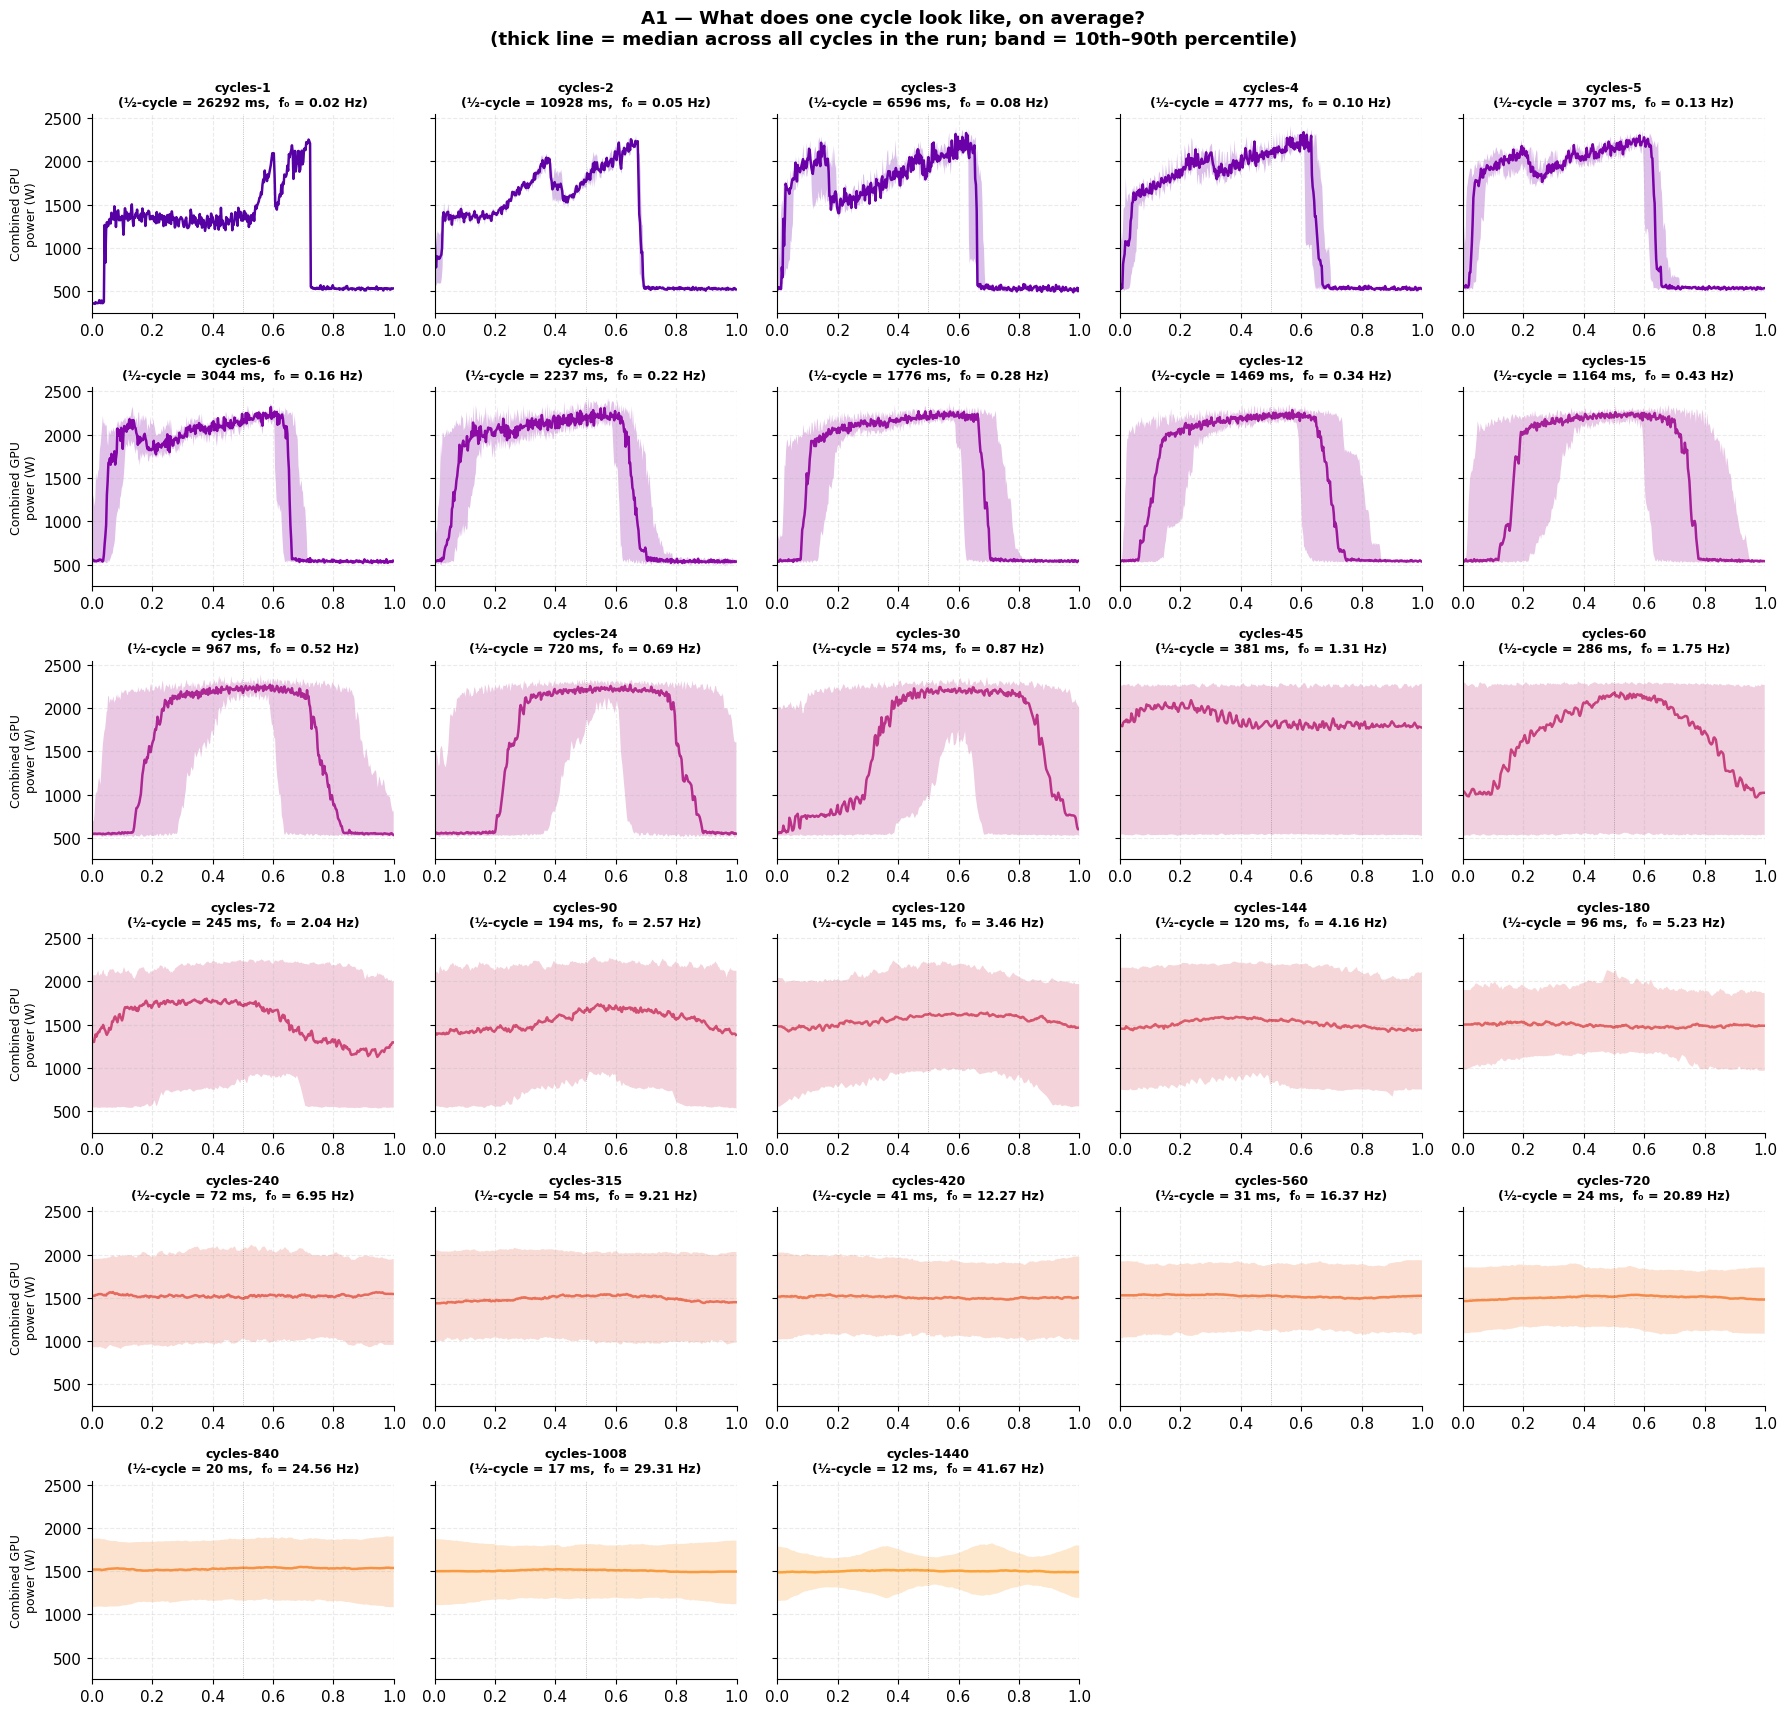

In [45]:
ncols = 5
nrows = (N_RUNS + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.8), sharey=True)
fig.suptitle("A1 — What does one cycle look like, on average?\n"
             "(thick line = median across all cycles in the run; band = 10th–90th percentile)",
             fontweight='bold', y=1.00)

for i, ax in enumerate(axes.flat):
    if i >= N_RUNS:
        ax.set_visible(False); continue
    (gpu_t, gpu_p), _ = run_node_data[i]
    folded = fold_cycles(gpu_t, gpu_p, cycle_counts[i])
    if folded is None:
        ax.set_visible(False); continue
    ax.fill_between(folded['phase'], folded['p10'], folded['p90'],
                    color=PALETTE[i], alpha=0.25, lw=0)
    ax.plot(folded['phase'], folded['median'], color=PALETTE[i], lw=1.8)
    ax.axvline(0.5, color='k', lw=0.5, ls=':', alpha=0.4)
    period_ms = folded['period_s'] * 1000
    ax.set_title(f"cycles-{cycle_counts[i]}\n"
                 f"(½-cycle = {period_ms/2:.0f} ms,  f₀ = {1/folded['period_s']:.2f} Hz)",
                 fontsize=9, fontweight='bold')
    if i % ncols == 0:
        ax.set_ylabel("Combined GPU\npower (W)", fontsize=9)
    if i // ncols == nrows - 1:
        ax.set_xlabel("Phase within cycle", fontsize=9)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


## A2 — One picture: how does cycle shape change as switching gets faster?

**The idea:** stack the folded medians from A1 into a 2D image. Y-axis is cycle count (slowest at bottom), x-axis is phase, color is power.

**How to read it:** at the bottom you should see two clear blocks (cold half + hot half). As you go up, the blocks blur and eventually merge into a uniform color — that's where the loop has averaged the workload to a constant.

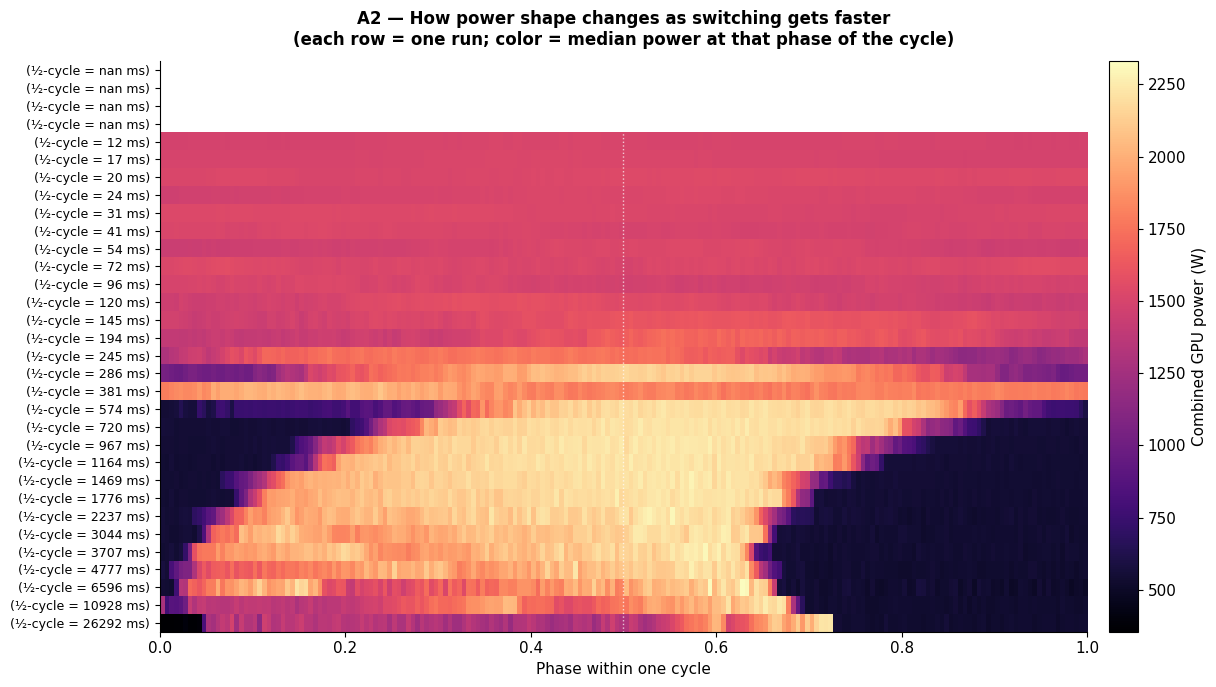

In [44]:
N_PHASE = 200
heatmap = np.full((N_RUNS, N_PHASE), np.nan)
period_ms_list = []
for i in range(N_RUNS):
    (gpu_t, gpu_p), _ = run_node_data[i]
    folded = fold_cycles(gpu_t, gpu_p, cycle_counts[i], n_phase_bins=N_PHASE)
    if folded is not None:
        heatmap[i] = folded['median']
        period_ms_list.append(folded['period_s'] * 1000)
    else:
        period_ms_list.append(np.nan)

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(heatmap, aspect='auto', origin='lower', cmap='magma',
               extent=[0, 1, -0.5, N_RUNS - 0.5], interpolation='nearest')
ax.set_yticks(range(N_RUNS))
ax.set_yticklabels([f"(½-cycle = {p/2:.0f} ms)"
                    for c, p in zip(cycle_counts, period_ms_list)],
                   fontsize=9)
ax.set_xlabel("Phase within one cycle", fontsize=11)
ax.set_title("A2 — How power shape changes as switching gets faster\n"
             "(each row = one run; color = median power at that phase of the cycle)",
             fontweight='bold', fontsize=12, pad=12)
ax.axvline(0.5, color='white', lw=1.0, ls=':', alpha=0.7)
plt.colorbar(im, ax=ax, label='Combined GPU power (W)', pad=0.02)
ax.grid(False)
plt.tight_layout()
plt.show()


## A3 — How big is the actual swing, and where's the −3 dB knee?

**The idea:** measure peak-to-peak swing (5/95 percentile) of the folded median for each run. The slowest run is the "free running" baseline — all others are scaled relative to it.

**How to read it:** the right panel shows a clear roll-off. The frequency where the swing falls to 50% of baseline is the controller's effective −3 dB bandwidth. That single number characterizes the SMU's ability to follow load changes.

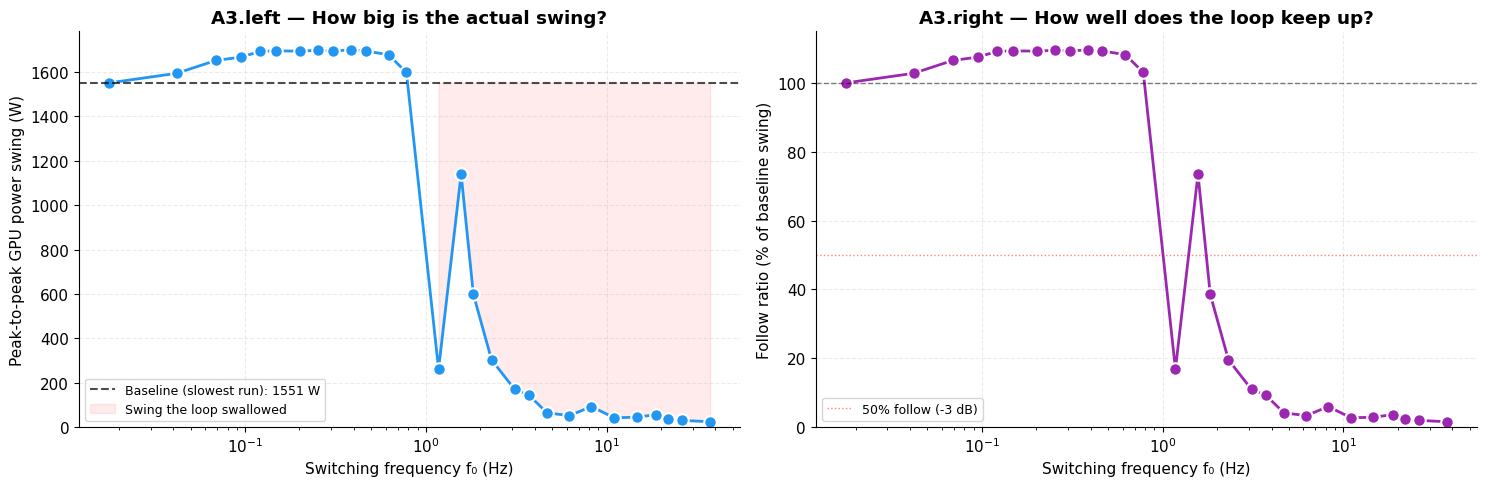

Free-running swing: 1551 W
Estimated -3 dB knee: 52.28 Hz (at cycles-2016)


In [33]:
def measured_swing(t, p, n_cycles):
    folded = fold_cycles(t, p, n_cycles)
    if folded is None:
        return np.nan
    return float(np.percentile(folded['median'], 95)
                 - np.percentile(folded['median'], 5))

# Slowest run is the free-running baseline
ideal_swing = measured_swing(*run_node_data[0][0], cycle_counts[0])

f0s    = np.array([f0_of_run(i) for i in range(N_RUNS)])
swings = np.array([measured_swing(*run_node_data[i][0], cycle_counts[i])
                   for i in range(N_RUNS)])
follow = 100 * swings / ideal_swing

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.semilogx(f0s, swings, 'o-', color='#2196F3', lw=2, ms=9,
            markeredgecolor='white', markeredgewidth=1.5)
ax.axhline(ideal_swing, color='black', ls='--', lw=1.5, alpha=0.7,
           label=f'Baseline (slowest run): {ideal_swing:.0f} W')
ax.fill_between(f0s, swings, ideal_swing, where=swings < ideal_swing,
                color='red', alpha=0.08, label='Swing the loop swallowed')
ax.set_xlabel("Switching frequency f₀ (Hz)", fontsize=11)
ax.set_ylabel("Peak-to-peak GPU power swing (W)", fontsize=11)
ax.set_title("A3.left — How big is the actual swing?", fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, ideal_swing * 1.15)

ax = axes[1]
ax.semilogx(f0s, follow, 'o-', color='#9C27B0', lw=2, ms=9,
            markeredgecolor='white', markeredgewidth=1.5)
ax.axhline(100, color='black', ls='--', lw=1.0, alpha=0.5)
ax.axhline(50, color='red', ls=':', lw=1.0, alpha=0.5,
           label='50% follow (-3 dB)')
ax.set_xlabel("Switching frequency f₀ (Hz)", fontsize=11)
ax.set_ylabel("Follow ratio (% of baseline swing)", fontsize=11)
ax.set_title("A3.right — How well does the loop keep up?",
             fontweight='bold')
ax.set_ylim(0, 115)
ax.legend(loc='lower left', fontsize=9)

# Auto-find -3 dB knee
half_idx = np.argmin(np.abs(follow - 50))
if abs(follow[half_idx] - 50) < 25:
    ax.annotate(f"≈ -3 dB knee\n(f ≈ {f0s[half_idx]:.2f} Hz)",
                xy=(f0s[half_idx], follow[half_idx]),
                xytext=(20, 30), textcoords='offset points',
                fontsize=10, fontweight='bold', color='#C62828',
                arrowprops=dict(arrowstyle='->', color='#C62828',
                                connectionstyle="arc3,rad=0.3"))

plt.tight_layout()
plt.show()

print(f"Free-running swing: {ideal_swing:.0f} W")
print(f"Estimated -3 dB knee: {f0s[half_idx]:.2f} Hz "
      f"(at cycles-{cycle_counts[half_idx]})")


## A4 — How is the GPU spending its time?

**The idea:** classify every sample of every run into three buckets — *near hot steady state*, *near cold steady state*, or *in transition*. Use the run's own 5/95 percentiles as the hot/cold reference points.

**How to read it:** at slow switching, the system spends ~50/50 time at the two steady states with very little transition. As switching gets faster, the gray "transition" region grows — eventually dominating, meaning the GPU is *always* slewing and never settles.

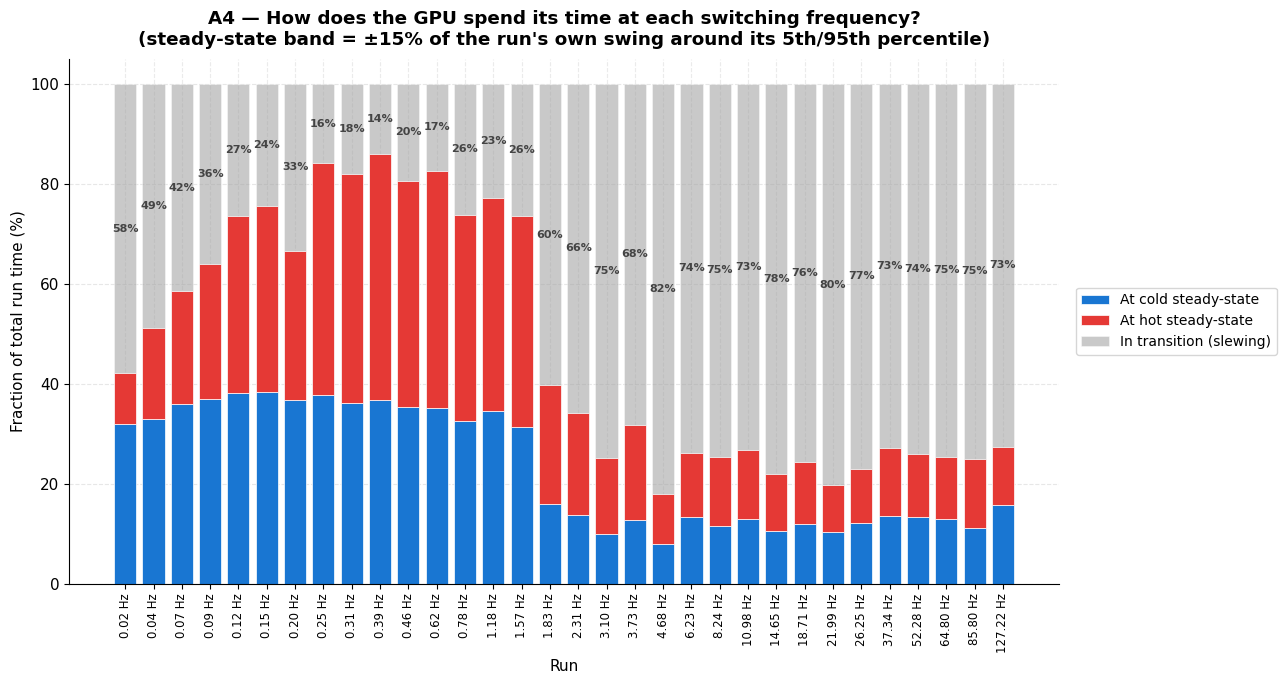

In [43]:
def time_in_zones(t, p, t_skip_head=3.0, t_skip_tail=1.0, zone_pct=15):
    t = np.asarray(t); p = np.asarray(p)
    m = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    p = p[m]
    if len(p) < 64:
        return 0.0, 0.0, 0.0
    p_lo = np.percentile(p, 5); p_hi = np.percentile(p, 95)
    band = (p_hi - p_lo) * zone_pct / 100.0
    near_cold = float(np.mean(p < p_lo + band))
    near_hot  = float(np.mean(p > p_hi - band))
    return near_cold, near_hot, 1 - near_cold - near_hot

cold_pct, hot_pct, trans_pct = [], [], []
for i in range(N_RUNS):
    (gpu_t, gpu_p), _ = run_node_data[i]
    c, h, tr = time_in_zones(gpu_t, gpu_p)
    cold_pct.append(c * 100); hot_pct.append(h * 100); trans_pct.append(tr * 100)
cold_pct = np.array(cold_pct); hot_pct = np.array(hot_pct); trans_pct = np.array(trans_pct)

fig, ax = plt.subplots(figsize=(13, 6.5))
x = np.arange(N_RUNS); width = 0.78
ax.bar(x, cold_pct, width, label='At cold steady-state',
       color='#1976D2', edgecolor='white', linewidth=0.5)
ax.bar(x, hot_pct, width, bottom=cold_pct, label='At hot steady-state',
       color='#E53935', edgecolor='white', linewidth=0.5)
ax.bar(x, trans_pct, width, bottom=cold_pct + hot_pct,
       label='In transition (slewing)', color='#9E9E9E', alpha=0.55,
       edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f"{f0_of_run(i):.2f} Hz"
                    for i, c in enumerate(cycle_counts)],
                   fontsize=8.5)
ax.set_ylabel("Fraction of total run time (%)", fontsize=11)
ax.set_xlabel("Run", fontsize=11)
ax.set_title("A4 — How does the GPU spend its time at each switching frequency?\n"
             "(steady-state band = ±15% of the run's own swing around its 5th/95th percentile)",
             fontweight='bold', pad=10)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
for i, (c, h, tr) in enumerate(zip(cold_pct, hot_pct, trans_pct)):
    if tr > 8:
        ax.text(i, c + h + tr / 2, f"{tr:.0f}%",
                ha='center', va='center', fontsize=8,
                color='#444', fontweight='bold')
plt.tight_layout()
plt.xticks(rotation=90)  # Rotates labels by 45 degrees

plt.show()


## A5 — What's the peak slew rate? Is up faster than down (VRM asymmetry)?

**The idea:** compute dP/dt directly from the trace. The 99th percentile of *positive* dP/dt is the peak up-slew the system can produce; the 99th percentile of *negative* dP/dt is the peak down-slew. If they differ, you've found a VRM asymmetry.

**How to read it:** the right panel typically rises (system is being driven harder), peaks at the resonant frequency, and falls (because at very high f, the swing itself is small). The peak value is the system's physical slew ceiling. If the red and blue lines diverge, you're seeing the cap-charge vs cap-discharge asymmetry of the regulator.

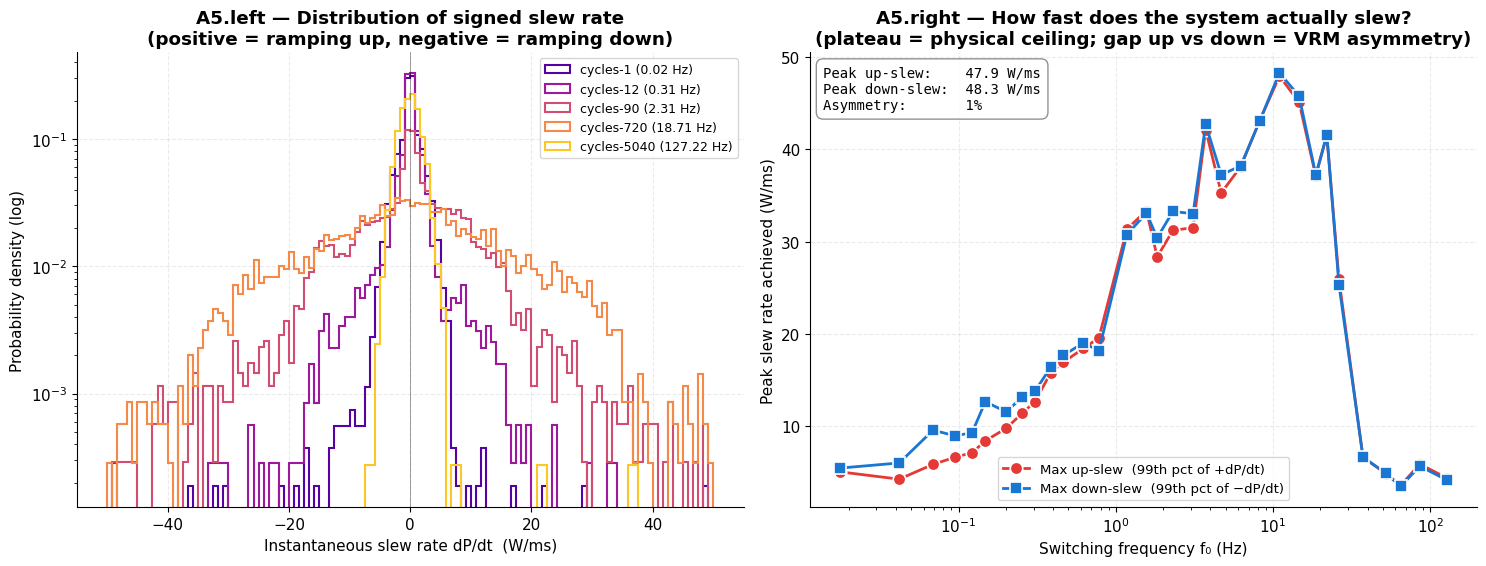

In [35]:
def slew_distribution(t, p, t_skip_head=3.0, t_skip_tail=1.0,
                      smooth_ms=3.0, fs_target=200.0):
    t = np.asarray(t); p = np.asarray(p)
    m = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, p = t[m], p[m]
    if len(t) < 64:
        return np.array([])
    fs = min(1.0 / np.median(np.diff(t)), fs_target)
    t_u = np.arange(t[0], t[-1], 1.0 / fs)
    p_u = np.interp(t_u, t, p)
    sigma = max(1, int((smooth_ms / 1000.0) * fs))
    p_s = gaussian_filter1d(p_u, sigma=sigma)
    return np.gradient(p_s, t_u)

up99, dn99, all_dps = [], [], []
for i in range(N_RUNS):
    (gpu_t, gpu_p), _ = run_node_data[i]
    dp = slew_distribution(gpu_t, gpu_p)
    all_dps.append(dp)
    if len(dp):
        up99.append(np.percentile(dp, 99))
        dn99.append(-np.percentile(dp, 1))
    else:
        up99.append(np.nan); dn99.append(np.nan)
up99 = np.array(up99); dn99 = np.array(dn99)
f0s = np.array([f0_of_run(i) for i in range(N_RUNS)])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
pick = [0, N_RUNS // 4, N_RUNS // 2, 3 * N_RUNS // 4, N_RUNS - 1]
for i in pick:
    if i < len(all_dps) and len(all_dps[i]):
        ax.hist(all_dps[i] / 1000, bins=120, range=(-50, 50),
                histtype='step', density=True, lw=1.5, color=PALETTE[i],
                label=f"cycles-{cycle_counts[i]} ({f0s[i]:.2f} Hz)")
ax.set_yscale('log')
ax.set_xlabel("Instantaneous slew rate dP/dt  (W/ms)", fontsize=11)
ax.set_ylabel("Probability density (log)", fontsize=11)
ax.set_title("A5.left — Distribution of signed slew rate\n"
             "(positive = ramping up, negative = ramping down)",
             fontweight='bold')
ax.axvline(0, color='black', lw=0.5, alpha=0.5)
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
ax.semilogx(f0s, up99 / 1000, 'o-', color='#E53935', lw=2, ms=9,
            label='Max up-slew  (99th pct of +dP/dt)',
            markeredgecolor='white', markeredgewidth=1.2)
ax.semilogx(f0s, dn99 / 1000, 's-', color='#1976D2', lw=2, ms=9,
            label='Max down-slew  (99th pct of −dP/dt)',
            markeredgecolor='white', markeredgewidth=1.2)
ax.set_xlabel("Switching frequency f₀ (Hz)", fontsize=11)
ax.set_ylabel("Peak slew rate achieved (W/ms)", fontsize=11)
ax.set_title("A5.right — How fast does the system actually slew?\n"
             "(plateau = physical ceiling; gap up vs down = VRM asymmetry)",
             fontweight='bold')
ax.legend(loc='lower center', fontsize=9.5)

peak_up = np.nanmax(up99) / 1000
peak_dn = np.nanmax(dn99) / 1000
asym_pct = abs(peak_up - peak_dn) / max(peak_up, peak_dn) * 100
ax.text(0.02, 0.97,
        f"Peak up-slew:    {peak_up:.1f} W/ms\n"
        f"Peak down-slew:  {peak_dn:.1f} W/ms\n"
        f"Asymmetry:       {asym_pct:.0f}%",
        transform=ax.transAxes, va='top', ha='left',
        family='monospace', fontsize=10,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85,
                  boxstyle='round,pad=0.5'))
plt.tight_layout()
plt.show()


## A6 — Does switching cost extra energy per operation?

**The idea:** every run does **exactly the same total operations** by design. So total energy ÷ ops is a fair single-number efficiency comparison. Use the slowest run (cycles-1) as the free-running baseline; everything else is a "switching tax" relative to it.

**Set `TOTAL_OPS` correctly for your benchmark.** It should be the total number of DGEMM + HPL panel calls each run does (constant across runs).

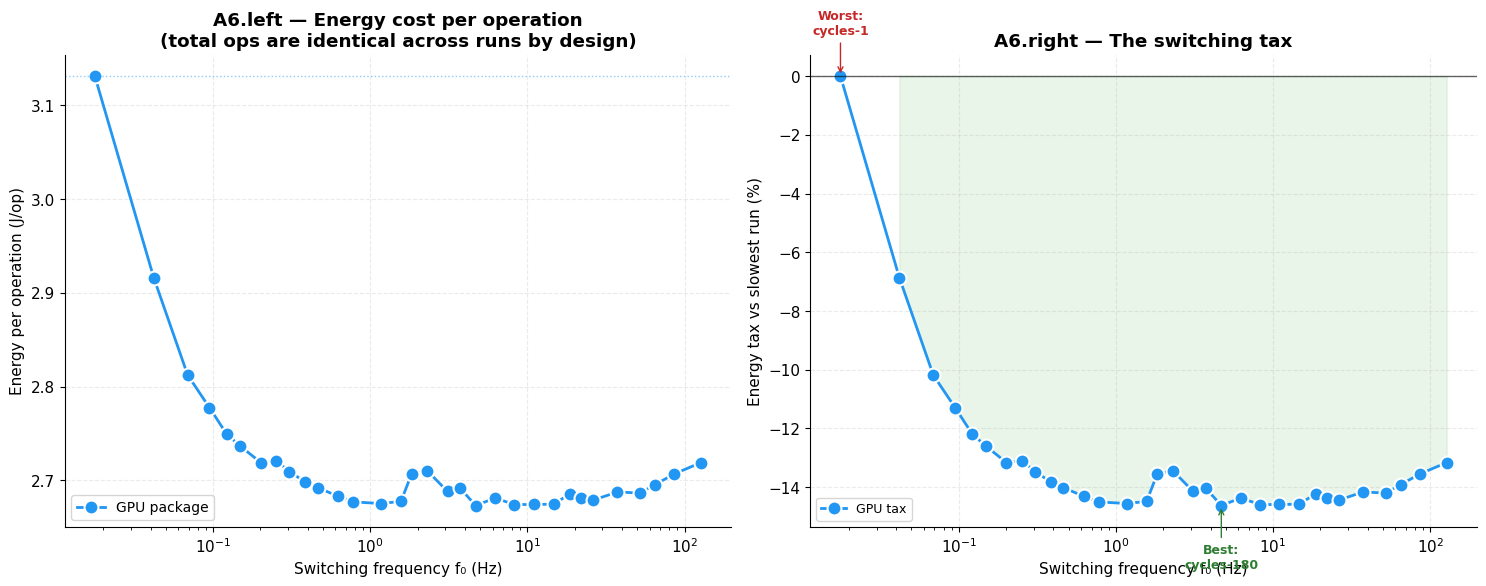

Run              f0 (Hz)   GPU J/op   Node J/op    Tax %
cycles-1           0.02       3.131          nan     +0.0%
cycles-2           0.04       2.916          nan     -6.9%
cycles-3           0.07       2.812          nan    -10.2%
cycles-4           0.09       2.778          nan    -11.3%
cycles-5           0.12       2.750          nan    -12.2%
cycles-6           0.15       2.737          nan    -12.6%
cycles-8           0.20       2.719          nan    -13.2%
cycles-10          0.25       2.721          nan    -13.1%
cycles-12          0.31       2.709          nan    -13.5%
cycles-15          0.39       2.698          nan    -13.8%
cycles-18          0.46       2.692          nan    -14.0%
cycles-24          0.62       2.683          nan    -14.3%
cycles-30          0.78       2.677          nan    -14.5%
cycles-45          1.18       2.675          nan    -14.6%
cycles-60          1.57       2.678          nan    -14.5%
cycles-72          1.83       2.707          nan    -13.5%

In [36]:
# >>>>> SET THIS for your benchmark <<<<<
TOTAL_OPS = 2 * 10080   # 10080 DGEMMs + 10080 HPL panels per run

E_gpu, E_node = [], []
for (gpu_t, gpu_p), (node_t, node_p) in run_node_data:
    E_gpu.append(float(np.trapezoid(gpu_p, gpu_t)))
    E_node.append(float(np.trapezoid(node_p, node_t))
                  if node_t is not None else np.nan)
E_gpu = np.array(E_gpu); E_node = np.array(E_node)
f0s = np.array([f0_of_run(i) for i in range(N_RUNS)])

J_op_gpu  = E_gpu  / TOTAL_OPS
J_op_node = E_node / TOTAL_OPS

# Use slowest run as baseline
baseline_gpu  = J_op_gpu[0]
baseline_node = J_op_node[0]
tax_gpu  = 100 * (J_op_gpu  / baseline_gpu  - 1)
tax_node = 100 * (J_op_node / baseline_node - 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.semilogx(f0s, J_op_gpu, 'o-', color='#2196F3', lw=2, ms=10,
            label='GPU package',
            markeredgecolor='white', markeredgewidth=1.5)
if not np.all(np.isnan(J_op_node)):
    ax.semilogx(f0s, J_op_node, 's-', color='#E53935', lw=2, ms=10,
                label='Whole node (incl. VRM losses + CPU)',
                markeredgecolor='white', markeredgewidth=1.5)
ax.axhline(baseline_gpu, color='#2196F3', ls=':', lw=1, alpha=0.5)
if not np.all(np.isnan(J_op_node)):
    ax.axhline(baseline_node, color='#E53935', ls=':', lw=1, alpha=0.5)
ax.set_xlabel("Switching frequency f₀ (Hz)", fontsize=11)
ax.set_ylabel("Energy per operation (J/op)", fontsize=11)
ax.set_title("A6.left — Energy cost per operation\n"
             "(total ops are identical across runs by design)",
             fontweight='bold')
ax.legend(loc='best', fontsize=10)

ax = axes[1]
ax.semilogx(f0s, tax_gpu, 'o-', color='#2196F3', lw=2, ms=10,
            label='GPU tax', markeredgecolor='white', markeredgewidth=1.5)
if not np.all(np.isnan(J_op_node)):
    ax.semilogx(f0s, tax_node, 's-', color='#E53935', lw=2, ms=10,
                label='Node tax', markeredgecolor='white', markeredgewidth=1.5)
ax.axhline(0, color='black', lw=1, alpha=0.6)
plot_tax = tax_node if not np.all(np.isnan(tax_node)) else tax_gpu
ax.fill_between(f0s, 0, plot_tax, where=(plot_tax > 0),
                alpha=0.12, color='#E53935')
ax.fill_between(f0s, 0, plot_tax, where=(plot_tax < 0),
                alpha=0.12, color='#4CAF50')
ax.set_xlabel("Switching frequency f₀ (Hz)", fontsize=11)
ax.set_ylabel("Energy tax vs slowest run (%)", fontsize=11)
ax.set_title("A6.right — The switching tax",
             fontweight='bold')
ax.legend(loc='best', fontsize=9)

best  = np.nanargmin(plot_tax)
worst = np.nanargmax(plot_tax)
ax.annotate(f"Best:\ncycles-{cycle_counts[best]}",
            xy=(f0s[best], plot_tax[best]),
            xytext=(0, -45), textcoords='offset points',
            ha='center', fontsize=9, color='#2E7D32', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2E7D32'))
ax.annotate(f"Worst:\ncycles-{cycle_counts[worst]}",
            xy=(f0s[worst], plot_tax[worst]),
            xytext=(0, 30), textcoords='offset points',
            ha='center', fontsize=9, color='#C62828', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C62828'))

plt.tight_layout()
plt.show()

# Print a table
print(f"{'Run':<14} {'f0 (Hz)':>9} {'GPU J/op':>10} {'Node J/op':>11} {'Tax %':>8}")
for i, c in enumerate(cycle_counts):
    print(f"cycles-{c:<6}  {f0s[i]:>8.2f}  {J_op_gpu[i]:>10.3f}  "
          f"{J_op_node[i]:>11.3f}  {plot_tax[i]:>+7.1f}%")


## A7 — When in each cycle does the brake (throttle) hit?

**The idea:** for runs that throttled, we want to know *when* in the cycle the brake fired. Fold throttle events on the cycle period and plot probability vs phase, alongside the folded power.

**How to read it:**
- Throttle peaks correlated with the *hot half* of the cycle = reactive throttle (controller responds to power overshoot)
- Throttle peaks at the *rising edge* = predictive throttle (controller pre-empts)
- Throttle uniform across phase = phase-locked control has been lost (not following the load anymore)
- No throttle at all = the workload stays within power envelope, or the loop has averaged everything out

NameError: name 't_c' is not defined

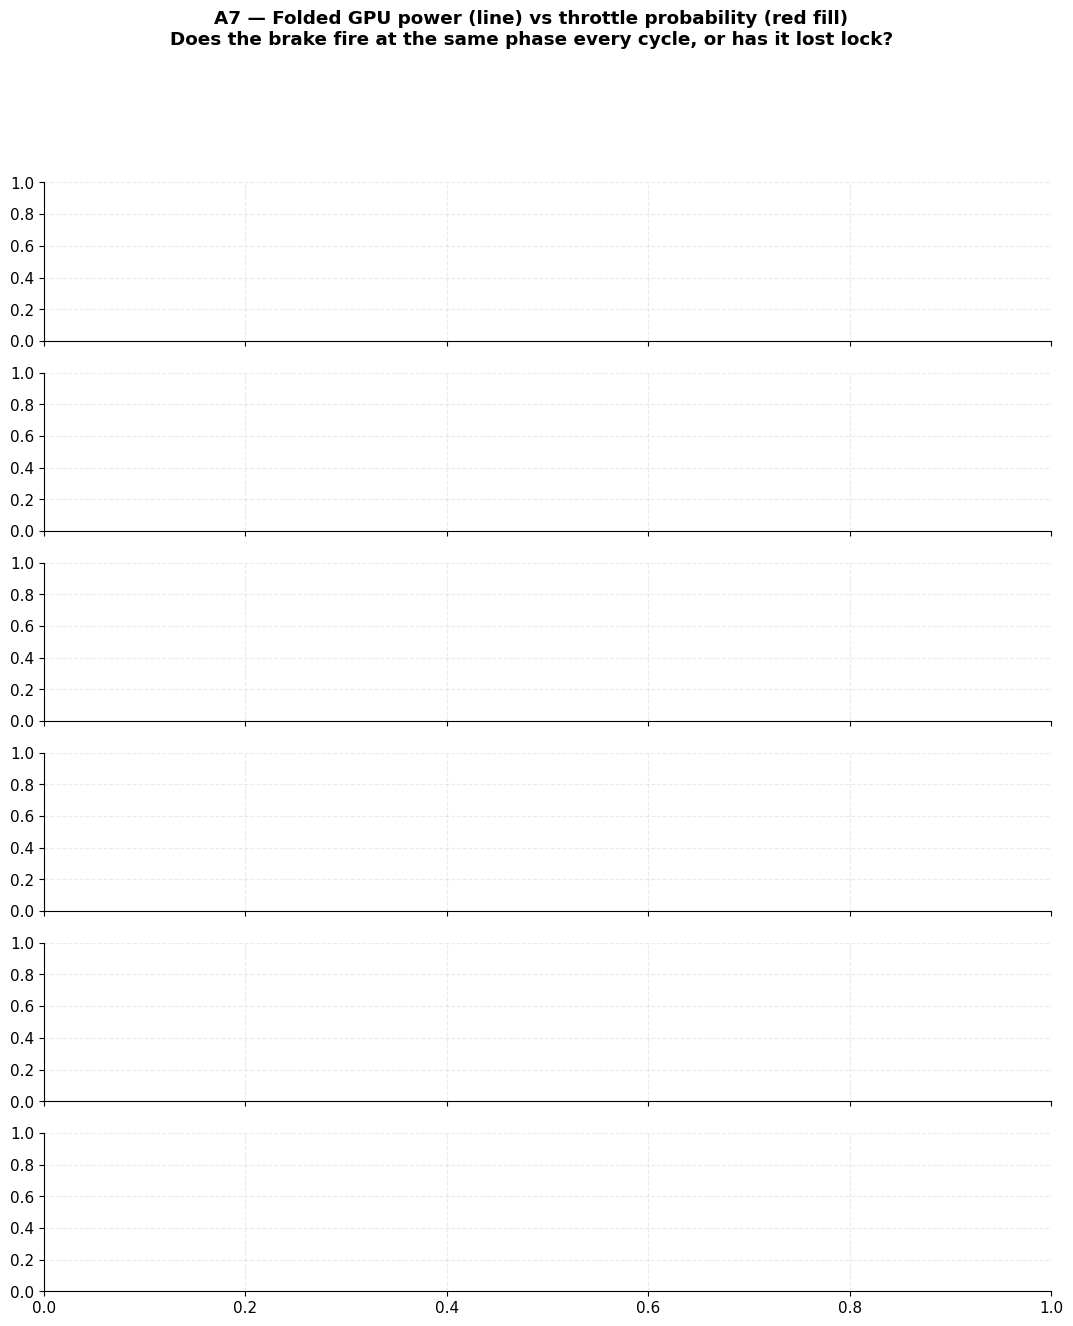

In [ ]:
def fold_throttle(t_clk, c_clk, n_cycles, t_skip_head=3.0, t_skip_tail=1.0,
                  bins=80, low=THROTTLE_LOW, high=THROTTLE_HIGH):
    t = np.asarray(t_clk); c = np.asarray(c_clk)
    m = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, c = t[m], c[m]
    if len(t) < 32:
        return None, None
    period = (t[-1] - t[0]) / n_cycles
    phase = ((t - t[0]) / period) % 1.0
    is_thr = ((c > low) & (c < high)).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    idx = np.clip(np.digitize(phase, edges) - 1, 0, bins - 1)
    counts = np.bincount(idx, minlength=bins)
    thr_counts = np.bincount(idx, weights=is_thr, minlength=bins)
    p_thr = np.where(counts > 0, thr_counts / counts, np.nan)
    return 0.5 * (edges[:-1] + edges[1:]), p_thr

# Pick 6 representative runs
pick = sorted(set([0, N_RUNS // 5, 2 * N_RUNS // 5,
                   3 * N_RUNS // 5, 4 * N_RUNS // 5, N_RUNS - 1]))
pick = [i for i in pick if i < N_RUNS]

fig, axes = plt.subplots(len(pick), 1, figsize=(13, 2.4 * len(pick)),
                         sharex=True)
fig.suptitle("A7 — Folded GPU power (line) vs throttle probability (red fill)\n"
             "Does the brake fire at the same phase every cycle, or has it lost lock?",
             fontweight='bold', y=1.00)

for ax_i, run_i in enumerate(pick):
    ax = axes[ax_i] if len(pick) > 1 else axes
    (gpu_t, gpu_p), _ = run_node_data[run_i]
    folded = fold_cycles(gpu_t, gpu_p, cycle_counts[run_i])
    t_c, c = run_clock_data[run_i]
    ph_thr, p_thr = fold_throttle(t_c, c, cycle_counts[run_i])
    if folded is None or ph_thr is None:
        ax.set_visible(False); continue

    ax.plot(folded['phase'], folded['median'], color=PALETTE[run_i], lw=2)
    ax.fill_between(folded['phase'], folded['p10'], folded['p90'],
                    color=PALETTE[run_i], alpha=0.15, lw=0)
    ax.set_ylabel("Power (W)", fontsize=10, color=PALETTE[run_i])
    ax.tick_params(axis='y', labelcolor=PALETTE[run_i])

    ax2 = ax.twinx()
    ax2.fill_between(ph_thr, 0, p_thr, color='#C62828', alpha=0.35, lw=0)
    ax2.plot(ph_thr, p_thr, color='#C62828', lw=1.4)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("P(throttle)", fontsize=10, color='#C62828')
    ax2.tick_params(axis='y', labelcolor='#C62828')
    ax2.grid(False)

    period_ms = folded['period_s'] * 1000
    ax.set_title(f"cycles-{cycle_counts[run_i]}   "
                 f"(½-cycle = {period_ms/2:.0f} ms,  "
                 f"f₀ = {1/folded['period_s']:.2f} Hz)",
                 fontsize=10, fontweight='bold', loc='left')
    ax.set_xlim(0, 1)

axes[-1].set_xlabel("Phase within cycle (0 → 1 = one full hot/cold cycle)",
                    fontsize=11)
plt.tight_layout()
plt.show()


## What to look for in your real data

1. **A1 / A2** — at what cycle count does the square wave shape clearly disappear? That's where your loop's bandwidth lies.
2. **A3** — read off the −3 dB knee. This is the single most useful characterization number.
3. **A4** — at slow switching, hot+cold should add to ~100%. As switching speeds up, the gray "in transition" bar grows. The cycle count where transition ≥ 50% means the loop is *always* slewing.
4. **A5** — the peak slew rate is the system's hard physical limit, useful for power capping policy. If up and down differ noticeably, that's a regulator design fingerprint.
5. **A6** — if `cycles-1` is the most efficient point, the controller does well at low f. If a *middle* cycle count is best, you have an unexpected efficiency sweet spot worth investigating.
6. **A7** — phase-locked throttle is a healthy sign that the controller is responding deterministically to the load. Throttle that flatlines across phase means the loop has stopped tracking and is just averaging.

### Things that can break (and how to know)
- `fold_cycles` returns `None` when there are fewer than 64 samples in the cropped window or fewer than 1 full cycle. The corresponding panel will be hidden, not crash.
- A6 needs `node_t` to compute node energy. If your run has no Cray PM data, the node curves silently drop out and the chart still works with GPU only.
- A7 needs throttling to actually be happening. If clocks never enter `[THROTTLE_LOW, THROTTLE_HIGH]`, the red fill will be empty — that's not a bug, it just means your run never throttled.